# EDA Notebook 1 — TweetEval Sentiment Dataset
**Thesis:** An Ethical Risk Assessment of Sentiment Analysis Models in Social Media Monitoring  
**Student:** Abhishek Tomar | PN1196973 | LJMU | September 2026

---

**Dataset:** `cardiffnlp/tweet_eval` (Hugging Face) — `sentiment` configuration  
**Role:** Primary sentiment dataset and primary linguistic-group audit  
**Classes:** Positive / Negative / Neutral  

**Methodological rule:** subgroup thresholds are pre-specified and are not adjusted merely to obtain larger groups. Small groups are reported with uncertainty/exploratory interpretation.


## Cell 1: Install Libraries

In [1]:
!pip install datasets emoji -q
print("Libraries installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 9.4 MB/s eta 0:00:00
Libraries installed.


## Cell 2: Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji
import json as _json
import os
from collections import Counter
from datasets import load_dataset

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
print("All libraries imported.")


All libraries imported.


## Cell 3: Load TweetEval
Loads all three splits (train, validation, test) and combines them.  
Labels: `0 = negative`, `1 = neutral`, `2 = positive`.

In [3]:
print("Loading TweetEval sentiment from Hugging Face (cardiffnlp/tweet_eval)...")
dataset = load_dataset("cardiffnlp/tweet_eval", "sentiment")

# Combine all splits
train_df = pd.DataFrame(dataset["train"]).assign(split="train")
val_df   = pd.DataFrame(dataset["validation"]).assign(split="validation")
test_df  = pd.DataFrame(dataset["test"]).assign(split="test")
df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Map integer labels to string labels
df["sentiment"] = df["label"].map({0: "negative", 1: "neutral", 2: "positive"})

print(f"Total rows loaded : {len(df):,}")
print(f"Columns           : {list(df.columns)}")
print(f"Splits            : {df['split'].value_counts().to_dict()}")
df.head(3)


Loading TweetEval sentiment from Hugging Face (cardiffnlp/tweet_eval)...


README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.78MB            

sentiment/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sentiment/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  901kB            

...

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Total rows loaded : 59,899
Columns           : ['text', 'label', 'split', 'sentiment']
Splits            : {'train': 45615, 'test': 12284, 'validation': 2000}


,text,label,split,sentiment
0,"""QT @user In the original draft of the 7th boo...",2,train,positive
1,"""Ben Smith / Smith (concussion) remains out of...",1,train,neutral
2,Sorry bout the stream last night I crashed out...,1,train,neutral


## Cell 4: Health Checks
Checks for missing values, duplicates, and empty texts.

In [4]:
print("=" * 55)
print("HEALTH CHECKS — TweetEval")
print("=" * 55)

print(f"Total rows     : {len(df):,}")
print(f"Total columns  : {df.shape[1]}")

print("\nMissing values per column:")
print(df.isnull().sum())

dupes = df.duplicated(subset=["text"]).sum()
empty = (df["text"].str.strip() == "").sum()
print(f"\nDuplicate texts : {dupes:,}")
print(f"Empty texts     : {empty}")

print("\nRows per split:")
print(df["split"].value_counts())


HEALTH CHECKS — TweetEval
Total rows     : 59,899
Total columns  : 4

Missing values per column:
text         0
label        0
split        0
sentiment    0
dtype: int64

Duplicate texts : 29
Empty texts     : 0

Rows per split:
split
train         45615
test          12284
validation     2000
Name: count, dtype: int64


## Cell 5: Label Distribution
Reports class prevalence descriptively. **No resampling or SMOTE decision is made from an arbitrary prevalence threshold in EDA.**


LABEL DISTRIBUTION
           Count  Percentage (%)
sentiment                       
neutral    27479           45.88
positive   21043           35.13
negative   11377           18.99

Interpretation:
  neutral: 45.9%
  positive: 35.1%
  negative: 19.0%
  Class prevalence is reported descriptively; imbalance handling is evaluated later under the modelling protocol.


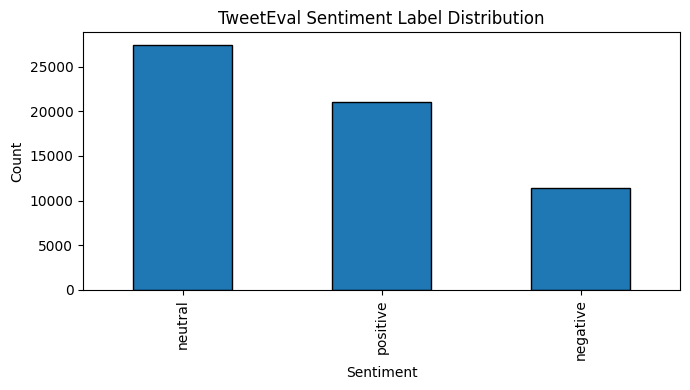

In [5]:
counts = df["sentiment"].value_counts()
pcts   = df["sentiment"].value_counts(normalize=True) * 100

print("LABEL DISTRIBUTION")
print(pd.DataFrame({"Count": counts, "Percentage (%)": pcts.round(2)}))

print("\nInterpretation:")
for label, pct in pcts.items():
    print(f"  {label}: {pct:.1f}%")
print("  Class prevalence is reported descriptively; imbalance handling is evaluated later under the modelling protocol.")

fig, ax = plt.subplots(figsize=(7, 4))
counts.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("TweetEval Sentiment Label Distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## Cell 6: Text Length Analysis
Measures character and whitespace-token counts. Very short posts are **described, not automatically removed as noise**.


Character count stats:
count    59899.0
mean       103.8
std         27.8
min          6.0
25%         85.0
50%        110.0
75%        125.0
max        200.0
Name: char_count, dtype: float64

Word count stats:
count    59899.0
mean        18.3
std          5.4
min          1.0
25%         15.0
50%         19.0
75%         22.0
max         35.0
Name: word_count, dtype: float64

Posts under 3 whitespace tokens : 45 (0.1%)
No automatic deletion rule is applied to short posts in EDA.

Mean word count per sentiment class:
sentiment
negative    19.0
neutral     17.9
positive    18.5
Name: word_count, dtype: float64


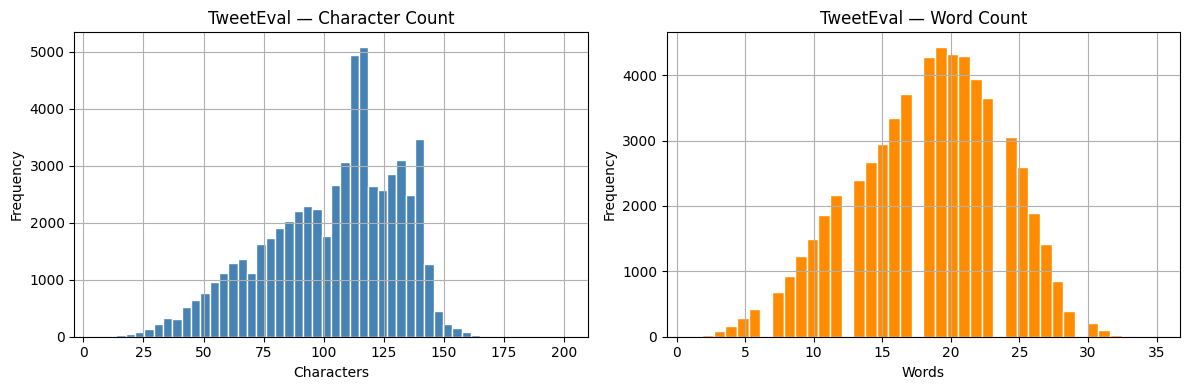

In [6]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("Character count stats:")
print(df["char_count"].describe().round(1))

print("\nWord count stats:")
print(df["word_count"].describe().round(1))

very_short = (df["word_count"] < 3).sum()
print(f"\nPosts under 3 whitespace tokens : {very_short:,} ({very_short/len(df)*100:.1f}%)")
print("No automatic deletion rule is applied to short posts in EDA.")

print("\nMean word count per sentiment class:")
print(df.groupby("sentiment")["word_count"].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["char_count"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("TweetEval — Character Count")
axes[0].set_xlabel("Characters")
axes[0].set_ylabel("Frequency")
df["word_count"].hist(bins=40, ax=axes[1], color="darkorange", edgecolor="white")
axes[1].set_title("TweetEval — Word Count")
axes[1].set_xlabel("Words")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("tweeteval_length.png", dpi=120)
plt.show()


## Cell 7: Define Sarcasm Pattern
Expanded pattern used consistently across all three dataset notebooks.

In [7]:
# Expanded sarcasm marker set — consistent across all three notebooks
# Covers: hashtags, colloquial irony phrases, negation + positive-word patterns
SARCASM_PATTERN = (
    r"#(?:sarcasm|sarcastic|irony|ironic|notreally|jk|justjoking|suuure|riiight)"
    r"|(?:yeah[,.]?\s*right)"
    r"|(?:as\s*if)"
    r"|(?:oh\s*great)"
    r"|(?:just\s*what\s*i\s*needed)"
    r"|(?:wow[,.]?\s*thanks)"
    r"|(?:totally[,!]+)"
    r"|(?:sure[.]+)"
    r"|(?:not\s*at\s*all)"
    r"|(?:big\s*surprise)"
    r"|(?:great\s*job\s+ruining)"
    r"|(?:not|never)\s+(?:great|amazing|awesome|fantastic|brilliant|wonderful|perfect|lovely)"
)
print("Sarcasm pattern defined. Covers hashtags, irony phrases, negation patterns.")


Sarcasm pattern defined. Covers hashtags, irony phrases, negation patterns.


## Cell 8: Linguistic Feature Detection
Detects emoji, slang, hashtags, mentions, URLs, negation, and sarcasm indicators in each post.

In [8]:
# ── Emoji features ────────────────────────────────────────────
def count_emojis(text):
    # Count full emoji sequences (e.g., 👍🏽) as one emoji, not each code point/modifier separately.
    return len(emoji.emoji_list(str(text)))

df["emoji_count"]   = df["text"].apply(count_emojis)
df["has_emoji"]     = df["emoji_count"] > 0
df["emoji_density"] = df["emoji_count"] / df["word_count"].replace(0, 1)

# ── Slang features ────────────────────────────────────────────
slang_terms = [
    "lol","lmao","omg","tbh","imo","imho","wtf","idk","ngl","smh","af","fr",
    "lowkey","highkey","slay","lit","goat","vibe","fire","wanna","gonna","gotta",
    "kinda","ur","bruh","bro","fam","dope","sick","sus","bussin","salty","cap",
    "bet","flex","ghost","clout","woke","ftw","ftl","epic","fail","rofl","ttyl",
    "brb","kk","np","nvm","thx","gr8","b4"
]
slang_pattern = r"\b(?:" + "|".join(re.escape(t) for t in slang_terms) + r")\b"
df["slang_count"] = df["text"].str.lower().str.count(slang_pattern)
df["has_slang"]   = df["slang_count"] > 0
df["slang_ratio"] = df["slang_count"] / df["word_count"].replace(0, 1)

# ── Other linguistic markers ──────────────────────────────────
df["hashtag_count"]     = df["text"].str.count(r"#\w+")
df["has_hashtag"]       = df["hashtag_count"] > 0
df["mention_count"]     = df["text"].str.count(r"@\w+")
df["has_mention"]       = df["mention_count"] > 0
df["has_url"]           = df["text"].str.contains(r"https?://\S+|www\.\S+", case=False, regex=True)
df["exclamation_count"] = df["text"].str.count(r"!")
df["has_negation"]      = df["text"].str.lower().str.contains(
    r"\b(not|no|never|cannot|can't|won't|doesn't|don't|didn't|isn't|aren't)\b", regex=True)
df["sarcasm_indicator"] = df["text"].str.lower().str.contains(
    SARCASM_PATTERN, regex=True)

# ── Print results ─────────────────────────────────────────────
print("Linguistic feature counts:")
features = {
    "Has emoji":          df["has_emoji"],
    "Has slang":          df["has_slang"],
    "Has hashtag":        df["has_hashtag"],
    "Has @mention":       df["has_mention"],
    "Has URL":            df["has_url"],
    "Has negation":       df["has_negation"],
    "Sarcasm indicator":  df["sarcasm_indicator"],
}
for name, col in features.items():
    print(f"  {name:<22}: {col.sum():>7,}  ({col.mean()*100:.1f}%)")


/tmp/ipykernel_5045/3323887870.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_negation"]      = df["text"].str.lower().str.contains(


Linguistic feature counts:
  Has emoji             :     809  (1.4%)
  Has slang             :   3,918  (6.5%)
  Has hashtag           :  13,703  (22.9%)
  Has @mention          :  19,047  (31.8%)
  Has URL               :     473  (0.8%)
  Has negation          :   9,507  (15.9%)
  Sarcasm indicator     :     112  (0.2%)


## Cell 9: Preliminary Linguistic Group Assignment
Applies the pre-specified rule thresholds to raw text. Final authoritative terminology is `emoji-heavy`, `slang-heavy`, `sarcasm-indicated`, `reference-unmarked`, and residual `other`.


Preliminary primary-group sizes:
  reference-unmarked  :  57,297  (95.66%)
  other               :   1,510  (2.52%)
  emoji-heavy         :     710  (1.19%)
  slang-heavy         :     270  (0.45%)
  sarcasm-indicated   :     112  (0.19%)

Primary group vs sentiment (row %):
sentiment           negative  neutral  positive
subgroup_primary                               
emoji-heavy             21.1     34.2      44.6
other                   15.0     57.9      27.1
reference-unmarked      19.1     45.7      35.2
sarcasm-indicated       24.1     39.3      36.6
slang-heavy             19.3     40.7      40.0

No rule threshold is adjusted in response to these counts.


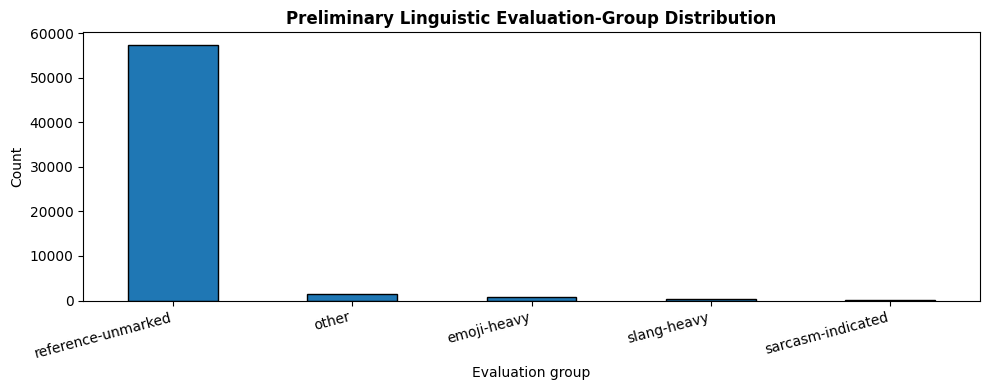

In [9]:
# ── Apply pre-specified thresholds ────────────────────────────
# emoji-heavy:          emoji_density > 0.05  (strictly greater than 5%)
# slang-heavy:          slang_ratio   > 0.10  (strictly greater than 10%)
# sarcasm-indicated:    matches SARCASM_PATTERN (surface-cue proxy, not gold sarcasm)
# reference-unmarked:   none of the three focal flags AND word_count >= 8
#
# IMPORTANT: thresholds are not changed after observing subgroup sizes.

df["subgroup_emoji"]   = df["emoji_density"] > 0.05
df["subgroup_slang"]   = df["slang_ratio"]   > 0.10
df["subgroup_sarcasm"] = df["sarcasm_indicator"].astype(bool)
df["subgroup_reference"] = (
    ~df["subgroup_emoji"] &
    ~df["subgroup_slang"] &
    ~df["subgroup_sarcasm"] &
    (df["word_count"] >= 8)
)

# Historical convenience flag only; the final audit below reports ALL overlap combinations.
df["subgroup_mixed_emoji_slang"] = df["subgroup_emoji"] & df["subgroup_slang"]

# ── Assign mutually-exclusive preliminary primary group ───────
def assign_primary(row):
    if row["subgroup_sarcasm"]:  return "sarcasm-indicated"
    if row["subgroup_emoji"]:    return "emoji-heavy"
    if row["subgroup_slang"]:    return "slang-heavy"
    if row["subgroup_reference"]:return "reference-unmarked"
    return "other"

df["subgroup_primary"] = df.apply(assign_primary, axis=1)

print("Preliminary primary-group sizes:")
sg = df["subgroup_primary"].value_counts()
for s, cnt in sg.items():
    pct = cnt / len(df) * 100
    print(f"  {s:<20}: {cnt:>7,}  ({pct:.2f}%)")

print("\nPrimary group vs sentiment (row %):")
print(pd.crosstab(
    df["subgroup_primary"], df["sentiment"], normalize="index"
).mul(100).round(1))

print("\nNo rule threshold is adjusted in response to these counts.")

fig, ax = plt.subplots(figsize=(10, 4))
sg.plot(kind="bar", ax=ax, edgecolor="black")
ax.set_title("Preliminary Linguistic Evaluation-Group Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Evaluation group")
ax.set_ylabel("Count")
ax.set_xticklabels(sg.index, rotation=15, ha="right")
plt.tight_layout()
plt.show()


## Cell 10: Label-Space Setup
`sentiment_3class` preserves TweetEval's primary three-class task. `sentiment_binary` is an auxiliary positive/negative slice used only where a binary external robustness comparison is justified. SemEval-2014 is handled separately as a domain/task-shift stress condition rather than being forced into a clean same-task track.


In [10]:
# Primary TweetEval label space
df["sentiment_3class"] = df["sentiment"].copy()

# Auxiliary binary-compatible slice for Sentiment140 robustness work only.
# Neutral true labels are excluded from this binary-compatible source slice;
# this does NOT redefine TweetEval's primary task.
df["sentiment_binary"] = df["sentiment"].map(
    {"positive": "positive", "negative": "negative", "neutral": None}
)
df["has_neutral"] = df["sentiment"] == "neutral"

print("Label-space columns created:")
print(f"  Primary TweetEval 3-class rows : {df['sentiment_3class'].notna().sum():,}")
print(f"  Binary-compatible source rows  : {df['sentiment_binary'].notna().sum():,}")
print(f"  Neutral rows                    : {df['has_neutral'].sum():,}")


Label-space columns created:
  Primary TweetEval 3-class rows : 59,899
  Binary-compatible source rows  : 32,420
  Neutral rows                    : 27,479


## Cell 11: Top Vocabulary per Sentiment Class
Shows the 20 most frequent words per class after removing stopwords.

In [11]:
stopwords = set([
    "the","a","an","is","are","was","were","i","you","he","she","it","we","they",
    "me","him","her","us","them","my","your","his","its","our","their","this","that",
    "and","or","but","if","in","on","at","to","for","of","with","by","from","so",
    "as","not","no","just","than","too","very","rt","via","amp","be","been","being",
    "have","has","had","do","does","did","will","would","can","could","shall","should"
])

for label in ["positive", "neutral", "negative"]:
    texts = df[df["sentiment"] == label]["text"].str.lower()
    words = " ".join(texts).split()
    words = [re.sub(r"[^a-z]", "", w) for w in words]
    words = [w for w in words if w and w not in stopwords and len(w) > 2]
    top20 = Counter(words).most_common(20)
    print(f"Top 20 words — {label.upper()}:")
    print("  " + ", ".join([f"{w}({c})" for w, c in top20]))
    print()


Top 20 words — POSITIVE:
  user(8447), tomorrow(3533), may(2313), day(2226), see(1685), night(1483), all(1443), going(1368), good(1297), friday(1296), out(1213), love(1154), time(1127), sunday(1100), like(1055), get(992), saturday(950), best(950), one(933), happy(913)

Top 20 words — NEUTRAL:
  user(11372), may(3051), tomorrow(2906), out(1583), going(1432), about(1426), day(1366), night(1295), all(1246), friday(1243), like(1202), sunday(1197), get(1162), new(1147), time(1136), see(1076), what(988), saturday(971), one(946), when(939)

Top 20 words — NEGATIVE:
  user(5920), may(1639), tomorrow(925), like(824), about(788), all(757), out(652), dont(609), trump(585), what(543), get(541), now(521), going(514), when(498), day(483), who(459), why(458), people(449), one(424), how(411)



## Cell 12: Emoji Frequency Analysis
Identifies the most frequently used emoji and their distribution across sentiment classes.

In [12]:
all_emojis = []
for text in df[df["has_emoji"]]["text"]:
    all_emojis.extend([item["emoji"] for item in emoji.emoji_list(str(text))])

print("Top 20 emoji in TweetEval:")
for em, cnt in Counter(all_emojis).most_common(20):
    print(f"  {em}  {emoji.demojize(em):<40} {cnt:>5,}")

print("\nMean emoji count per sentiment class:")
print(df.groupby("sentiment")["emoji_count"].mean().round(2))

print("\nSentiment distribution in emoji-heavy posts:")
print(df[df["subgroup_emoji"]]["sentiment"].value_counts(normalize=True).mul(100).round(1))


Top 20 emoji in TweetEval:
  😂  :face_with_tears_of_joy:                   191
  😭  :loudly_crying_face:                        74
  😍  :smiling_face_with_heart-eyes:              71
  ❤️  :red_heart:                                 48
  🤔  :thinking_face:                             31
  ❤  :red_heart:                                 29
  🇺🇸  :United_States:                             27
  🙄  :face_with_rolling_eyes:                    27
  💙  :blue_heart:                                26
  🔥  :fire:                                      23
  😊  :smiling_face_with_smiling_eyes:            21
  😩  :weary_face:                                18
  👍  :thumbs_up:                                 18
  😢  :crying_face:                               18
  👌  :OK_hand:                                   16
  😁  :beaming_face_with_smiling_eyes:            16
  😎  :smiling_face_with_sunglasses:              15
  🙏  :folded_hands:                              14
  😡  :enraged_face:                

## Cell 13: EDA Summary
Full summary of all key statistics for TweetEval.

In [13]:
print("=" * 55)
print("TweetEval — COMPLETE EDA SUMMARY")
print("=" * 55)

summary = {
    "Total rows":              f"{len(df):,}",
    "Duplicate texts":         f"{df.duplicated('text').sum():,}",
    "Positive (3-class)":      f"{(df['sentiment']=='positive').sum():,}  ({(df['sentiment']=='positive').mean()*100:.1f}%)",
    "Neutral":                 f"{(df['sentiment']=='neutral').sum():,}  ({(df['sentiment']=='neutral').mean()*100:.1f}%)",
    "Negative":                f"{(df['sentiment']=='negative').sum():,}  ({(df['sentiment']=='negative').mean()*100:.1f}%)",
    "Mean word count":         f"{df['word_count'].mean():.1f}",
    "Has emoji":               f"{df['has_emoji'].sum():,}  ({df['has_emoji'].mean()*100:.1f}%)",
    "Has slang":               f"{df['has_slang'].sum():,}  ({df['has_slang'].mean()*100:.1f}%)",
    "Sarcasm-indicated":       f"{df['sarcasm_indicator'].sum():,}  ({df['sarcasm_indicator'].mean()*100:.1f}%)",
    "Subgroup emoji-heavy":    f"{(df['subgroup_primary']=='emoji-heavy').sum():,}",
    "Subgroup slang-heavy":    f"{(df['subgroup_primary']=='slang-heavy').sum():,}",
    "Subgroup sarcasm-indicated": f"{(df['subgroup_primary']=='sarcasm-indicated').sum():,}",
    "Subgroup reference-unmarked": f"{(df['subgroup_primary']=='reference-unmarked').sum():,}",
    "Track A rows (3-class)":  f"{df['sentiment_3class'].notna().sum():,}",
    "Track B rows (binary)":   f"{df['sentiment_binary'].notna().sum():,}",
}
for k, v in summary.items():
    print(f"  {k:<35}: {v}")

df_tweeteval = df.copy()
print("\nDataFrame saved as df_tweeteval")


TweetEval — COMPLETE EDA SUMMARY
  Total rows                         : 59,899
  Duplicate texts                    : 29
  Positive (3-class)                 : 21,043  (35.1%)
  Neutral                            : 27,479  (45.9%)
  Negative                           : 11,377  (19.0%)
  Mean word count                    : 18.3
  Has emoji                          : 809  (1.4%)
  Has slang                          : 3,918  (6.5%)
  Sarcasm-indicated                  : 112  (0.2%)
  Subgroup emoji-heavy               : 710
  Subgroup slang-heavy               : 270
  Subgroup sarcasm-indicated         : 112
  Subgroup reference-unmarked        : 57,297
  Track A rows (3-class)             : 59,899
  Track B rows (binary)              : 32,420

DataFrame saved as df_tweeteval


## Cell 14: Save Preliminary Prepared Data
Saves the prepared dataframe to the existing Drive EDA staging path. The **authoritative freeze outputs are written by the final audit block below**.


In [14]:
# ── Save to parquet ───────────────────────────────────────────
# Saves the DataFrame so Notebook 4 can load it without re-running this notebook
# Files are stored in Colab local storage (/content/)
# Mount Google Drive first if you want them to persist across sessions

save_path = "/content/df_tweeteval.parquet"
df_tweeteval.to_parquet(save_path, index=False)
print(f"Saved {len(df_tweeteval):,} rows to {save_path}")

# ── Save preliminary prepared dataframe to the existing Drive staging path ──
from google.colab import drive
drive.mount("/content/drive")
df_tweeteval.to_parquet("/content/drive/MyDrive/My_Data/upgrad-ljmu-thesis/LJMU Thesis/Dataset_Exploration/EDA/df_tweeteval.parquet")


Saved 59,899 rows to /content/df_tweeteval.parquet
Mounted at /content/drive


## FINAL FREEZE AUDIT — TweetEval

This block is the **authoritative EDA-01 audit** used before Chapter 3 is frozen. Earlier cells are retained for exploratory continuity, but this block supersedes the earlier `formal`/`sarcasm` display labels with **`reference-unmarked`** and **`sarcasm-indicated`**.

**Important:** the existing rule thresholds are audited as specified; they are **not adjusted in response to subgroup size**. Small groups are flagged for cautious/exploratory interpretation rather than used to tune the rules.


In [15]:
# ============================================================
# EDA-01 FINAL FREEZE CONFIG + INTEGRITY AUDIT
# ============================================================
from pathlib import Path
import itertools
import json

# --- Frozen rule specification for THIS audit ---
EDA_FREEZE_CONFIG = {
    "dataset": "cardiffnlp/tweet_eval",
    "configuration": "sentiment",
    "source_text": "raw TweetEval text",
    "case_handling": {
        "slang": "lowercased before regex matching",
        "sarcasm": "lowercased before regex matching",
        "emoji": "full emoji sequences counted from raw text using emoji.emoji_list; modifiers are not counted as standalone emoji"
    },
    "word_count_denominator": "whitespace token count from raw text via str.split()",
    "emoji_heavy": {
        "formula": "emoji_count / word_count",
        "operator": ">",
        "threshold": 0.05
    },
    "slang_heavy": {
        "formula": "slang_count / word_count",
        "operator": ">",
        "threshold": 0.10,
        "lexicon_version": "study_slang_v1_51_terms",
        "lexicon_size": len(slang_terms),
        "lexicon": slang_terms
    },
    "sarcasm_indicated": {
        "cue_set_version": "study_sarcasm_proxy_v1",
        "definition": "matches predefined surface-cue regex; not gold-standard authorial sarcasm",
        "regex": SARCASM_PATTERN
    },
    "reference_unmarked": {
        "definition": "no focal emoji-heavy, slang-heavy or sarcasm-indicated flag AND word_count >= 8",
        "minimum_word_count": 8
    },
    "priority_rule": [
        "sarcasm-indicated",
        "emoji-heavy",
        "slang-heavy",
        "reference-unmarked",
        "other"
    ],
    "minimum_n_for_stable_quantitative_interpretation": 30,
    "below_minimum_n": "report descriptively/exploratorily; do not treat as stable subgroup evidence",
    "threshold_tuning_policy": "no threshold is changed after observing subgroup sizes"
}

# Official split assertions
EXPECTED_SPLITS = {"train": 45615, "validation": 2000, "test": 12284}
actual_splits = df["split"].value_counts().to_dict()
assert actual_splits == EXPECTED_SPLITS, f"Unexpected split counts: {actual_splits}"

# Core health audit
integrity = {
    "total_rows": int(len(df)),
    "missing_text": int(df["text"].isna().sum()),
    "empty_text": int((df["text"].fillna("").str.strip() == "").sum()),
    "duplicate_extra_rows": int(df.duplicated(subset=["text"]).sum()),
}

# Duplicate-group audit
dup_groups = (
    df.groupby("text", dropna=False)
      .agg(
          n_rows=("text", "size"),
          n_labels=("label", "nunique"),
          n_splits=("split", "nunique"),
          labels=("label", lambda s: "|".join(map(str, sorted(set(s))))),
          splits=("split", lambda s: "|".join(sorted(set(s))))
      )
      .reset_index()
)
dup_groups = dup_groups[dup_groups["n_rows"] > 1].copy()
dup_groups["cross_split"] = dup_groups["n_splits"] > 1
dup_groups["conflicting_label"] = dup_groups["n_labels"] > 1

integrity.update({
    "duplicate_text_groups": int(len(dup_groups)),
    "cross_split_duplicate_text_groups": int(dup_groups["cross_split"].sum()),
    "conflicting_label_duplicate_text_groups": int(dup_groups["conflicting_label"].sum()),
    "cross_split_conflicting_text_groups": int(
        (dup_groups["cross_split"] & dup_groups["conflicting_label"]).sum()
    )
})

print("=" * 72)
print("TWEETEVAL — FINAL INTEGRITY AUDIT")
print("=" * 72)
for k, v in integrity.items():
    print(f"{k:<42}: {v:,}" if isinstance(v, int) else f"{k:<42}: {v}")

print("\nClass distribution by split:")
class_by_split = pd.crosstab(df["split"], df["sentiment"])
class_by_split["TOTAL"] = class_by_split.sum(axis=1)
print(class_by_split)

print("\nDuplicate group summary:")
print(
    dup_groups[["n_rows","n_labels","n_splits","cross_split","conflicting_label"]]
    .describe(include="all")
)

if integrity["cross_split_duplicate_text_groups"] > 0:
    print("\nWARNING: Cross-split duplicate texts exist and must be reviewed before modelling.")
else:
    print("\nPASS: No cross-split duplicate text groups detected.")

if integrity["conflicting_label_duplicate_text_groups"] > 0:
    print("WARNING: Some duplicate texts carry conflicting sentiment labels.")
else:
    print("PASS: No conflicting-label duplicate text groups detected.")


TWEETEVAL — FINAL INTEGRITY AUDIT
total_rows                                : 59,899
missing_text                              : 0
empty_text                                : 0
duplicate_extra_rows                      : 29
duplicate_text_groups                     : 25
cross_split_duplicate_text_groups         : 0
conflicting_label_duplicate_text_groups   : 3
cross_split_conflicting_text_groups       : 0

Class distribution by split:
sentiment   negative  neutral  positive  TOTAL
split                                         
test            3972     5937      2375  12284
train           7093    20673     17849  45615
validation       312      869       819   2000

Duplicate group summary:
           n_rows   n_labels  n_splits cross_split conflicting_label
count   25.000000  25.000000      25.0          25                25
unique        NaN        NaN       NaN           1                 2
top           NaN        NaN       NaN       False             False
freq          NaN       

In [16]:
# ============================================================
# PRE-PRIORITY FLAGS, OVERLAPS, AND FINAL PRIMARY GROUPS
# ============================================================

# Independent focal flags from the already-computed raw-text features
df["is_emoji_heavy"] = df["emoji_density"] > 0.05
df["is_slang_heavy"] = df["slang_ratio"] > 0.10
df["is_sarcasm_indicated"] = df["sarcasm_indicator"].astype(bool)

# Reference candidate is explicitly unmarked by the three focal conditions
df["is_reference_candidate"] = (
    ~df["is_emoji_heavy"]
    & ~df["is_slang_heavy"]
    & ~df["is_sarcasm_indicated"]
    & (df["word_count"] >= 8)
)

FOCAL_FLAGS = ["is_emoji_heavy", "is_slang_heavy", "is_sarcasm_indicated"]

# Pairwise overlap matrix BEFORE exclusivity/priority
overlap_matrix = pd.DataFrame(index=FOCAL_FLAGS, columns=FOCAL_FLAGS, dtype=int)
for a in FOCAL_FLAGS:
    for b in FOCAL_FLAGS:
        overlap_matrix.loc[a, b] = int((df[a] & df[b]).sum())

# Full overlap-pattern audit
def _pattern(row):
    active = [f.replace("is_","") for f in FOCAL_FLAGS if row[f]]
    return "+".join(active) if active else "none"

df["focal_flag_count"] = df[FOCAL_FLAGS].sum(axis=1)
df["focal_overlap_pattern"] = df.apply(_pattern, axis=1)
overlap_patterns = (
    df["focal_overlap_pattern"]
      .value_counts()
      .rename_axis("pattern")
      .reset_index(name="count")
)
overlap_patterns["pct"] = overlap_patterns["count"] / len(df) * 100

# Final mutually-exclusive primary group using the prespecified priority
def assign_primary_final(row):
    if row["is_sarcasm_indicated"]:
        return "sarcasm-indicated"
    if row["is_emoji_heavy"]:
        return "emoji-heavy"
    if row["is_slang_heavy"]:
        return "slang-heavy"
    if row["is_reference_candidate"]:
        return "reference-unmarked"
    return "other"

df["subgroup_primary_final"] = df.apply(assign_primary_final, axis=1)

# Split-wise final counts
subgroup_by_split = pd.crosstab(df["split"], df["subgroup_primary_final"])
subgroup_by_split_pct = pd.crosstab(
    df["split"], df["subgroup_primary_final"], normalize="index"
).mul(100).round(3)

# Split + subgroup + sentiment counts and row percentages
subgroup_class_counts = (
    df.groupby(["split","subgroup_primary_final","sentiment"])
      .size()
      .rename("count")
      .reset_index()
)
subgroup_class_pct = subgroup_class_counts.copy()
subgroup_class_pct["pct_within_split_subgroup"] = (
    subgroup_class_pct["count"]
    / subgroup_class_pct.groupby(["split","subgroup_primary_final"])["count"].transform("sum")
    * 100
)

print("=" * 72)
print("PRE-PRIORITY OVERLAP AUDIT")
print("=" * 72)
print(overlap_matrix)

print("\nOverlap patterns:")
print(overlap_patterns.to_string(index=False))

print("\nFinal subgroup counts by split:")
print(subgroup_by_split)

print("\nFinal subgroup percentages within each split:")
print(subgroup_by_split_pct)

# Eligibility/stability flag for held-out test interpretation
test_counts = (
    df.loc[df["split"] == "test", "subgroup_primary_final"]
      .value_counts()
      .rename_axis("subgroup")
      .reset_index(name="n_test")
)
MIN_N = EDA_FREEZE_CONFIG["minimum_n_for_stable_quantitative_interpretation"]
test_counts["interpretation_status"] = np.where(
    test_counts["n_test"] >= MIN_N,
    "eligible_for_quantitative_interpretation",
    "exploratory_descriptive_only"
)

print("\nHeld-out test subgroup sufficiency:")
print(test_counts.to_string(index=False))

print("\nRULE: subgroup thresholds are NOT adjusted because a group is small.")


PRE-PRIORITY OVERLAP AUDIT
                      is_emoji_heavy  is_slang_heavy  is_sarcasm_indicated
is_emoji_heavy                 711.0            10.0                   1.0
is_slang_heavy                  10.0           280.0                   0.0
is_sarcasm_indicated             1.0             0.0                 112.0

Overlap patterns:
                      pattern  count       pct
                         none  58807 98.176931
                  emoji_heavy    700  1.168634
                  slang_heavy    270  0.450759
            sarcasm_indicated    111  0.185312
      emoji_heavy+slang_heavy     10  0.016695
emoji_heavy+sarcasm_indicated      1  0.001669

Final subgroup counts by split:
subgroup_primary_final  emoji-heavy  other  reference-unmarked  sarcasm-indicated  slang-heavy
split                                                                                         
test                            710   1112               10388                 14           60
train  

In [17]:
# ============================================================
# SAVE AUTHORITATIVE EDA-01 OUTPUTS
# ============================================================
from google.colab import drive
import os

if not os.path.exists("/content/drive/MyDrive"):
    drive.mount("/content/drive")

# Staging location that is known to exist in the current Drive hierarchy.
# These files can then be moved into the new authoritative EDA/Results folder.
OUT_DIR = Path(
    "/content/drive/MyDrive/My_Data/upgrad-ljmu-thesis/"
    "LJMU Thesis/Dataset_Exploration/EDA/EDA_FINAL_RESULTS_STAGING"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Machine-readable tables
class_by_split.to_csv(OUT_DIR / "tweeteval_class_distribution_by_split.csv")
dup_groups.to_csv(OUT_DIR / "tweeteval_duplicate_audit.csv", index=False)
overlap_matrix.to_csv(OUT_DIR / "tweeteval_overlap_matrix.csv")
overlap_patterns.to_csv(OUT_DIR / "tweeteval_overlap_patterns.csv", index=False)
subgroup_by_split.to_csv(OUT_DIR / "tweeteval_subgroup_counts_by_split.csv")
subgroup_by_split_pct.to_csv(OUT_DIR / "tweeteval_subgroup_pct_by_split.csv")
subgroup_class_counts.to_csv(OUT_DIR / "tweeteval_subgroup_class_counts_by_split.csv", index=False)
subgroup_class_pct.to_csv(OUT_DIR / "tweeteval_subgroup_class_pct_by_split.csv", index=False)
test_counts.to_csv(OUT_DIR / "tweeteval_test_subgroup_sufficiency.csv", index=False)

with open(OUT_DIR / "tweeteval_integrity_summary.json", "w") as f:
    json.dump(integrity, f, indent=2)

with open(OUT_DIR / "tweeteval_freeze_config.json", "w") as f:
    json.dump(EDA_FREEZE_CONFIG, f, indent=2)

# Authoritative prepared dataframe for later EDA notebooks.
df_tweeteval_final = df.copy()
df_tweeteval_final.to_parquet(
    OUT_DIR / "df_tweeteval_final.parquet",
    index=False
)

print("=" * 72)
print("EDA-01 AUTHORITATIVE OUTPUTS SAVED")
print("=" * 72)
print(f"Output directory: {OUT_DIR}")
for fp in sorted(OUT_DIR.iterdir()):
    print(" -", fp.name)

print("\nEDA-01 is ready for freeze review after these outputs are inspected.")


EDA-01 AUTHORITATIVE OUTPUTS SAVED
Output directory: /content/drive/MyDrive/My_Data/upgrad-ljmu-thesis/LJMU Thesis/Dataset_Exploration/EDA/EDA_FINAL_RESULTS_STAGING
 - df_tweeteval_final.parquet
 - tweeteval_class_distribution_by_split.csv
 - tweeteval_duplicate_audit.csv
 - tweeteval_freeze_config.json
 - tweeteval_integrity_summary.json
 - tweeteval_overlap_matrix.csv
 - tweeteval_overlap_patterns.csv
 - tweeteval_subgroup_class_counts_by_split.csv
 - tweeteval_subgroup_class_pct_by_split.csv
 - tweeteval_subgroup_counts_by_split.csv
 - tweeteval_subgroup_pct_by_split.csv
 - tweeteval_test_subgroup_sufficiency.csv

EDA-01 is ready for freeze review after these outputs are inspected.
